In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n = 1000

departments = ["Engineering", "Safety", "Operations", "Maintenance", "Quality"]
risk_levels = ["Low", "Medium", "High"]
reasons = ["Incomplete description", "Missing risk assessment", "Poor mitigation plan", "No issue", "Late submission"]

data = pd.DataFrame({
    "ISP_ID": range(1, n + 1),
    "Engineer_ID": np.random.randint(1000, 1100, n),
    "Department": np.random.choice(departments, n),
    "Risk_Level": np.random.choice(risk_levels, n, p=[0.4, 0.4, 0.2]),
    "Completion_Time_Minutes": np.random.randint(5, 90, n),
    "Quality_Score": np.random.randint(50, 101, n),
    "Reason_for_Low_Quality": np.random.choice(reasons, n),
    "Date": [datetime(2023, 1, 1) + timedelta(days=int(x)) for x in np.random.randint(0, 240, n)]
})

data["Low_Quality"] = np.where(data["Quality_Score"] < 70, 1, 0)

data.to_csv("isp_safety_data.csv", index=False)

data.head()

,ISP_ID,Engineer_ID,Department,Risk_Level,Completion_Time_Minutes,Quality_Score,Reason_for_Low_Quality,Date,Low_Quality
0,1,1051,Safety,Medium,55,82,Incomplete description,2023-03-28,0
1,2,1092,Engineering,High,89,98,Late submission,2023-02-10,0
2,3,1014,Maintenance,Low,50,70,No issue,2023-05-03,0
3,4,1071,Operations,Low,25,58,Poor mitigation plan,2023-03-16,1
4,5,1060,Safety,Low,48,55,Poor mitigation plan,2023-02-11,1


In [ ]:
import pandas as pd

df = pd.read_csv("isp_safety_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.drop_duplicates(inplace=True)

df.fillna("Unknown", inplace=True)

df.to_csv("cleaned_isp_safety_data.csv", index=False)

df.head()

,ISP_ID,Engineer_ID,Department,Risk_Level,Completion_Time_Minutes,Quality_Score,Reason_for_Low_Quality,Date,Low_Quality
0,1,1051,Safety,Medium,55,82,Incomplete description,2023-03-28,0
1,2,1092,Engineering,High,89,98,Late submission,2023-02-10,0
2,3,1014,Maintenance,Low,50,70,No issue,2023-05-03,0
3,4,1071,Operations,Low,25,58,Poor mitigation plan,2023-03-16,1
4,5,1060,Safety,Low,48,55,Poor mitigation plan,2023-02-11,1


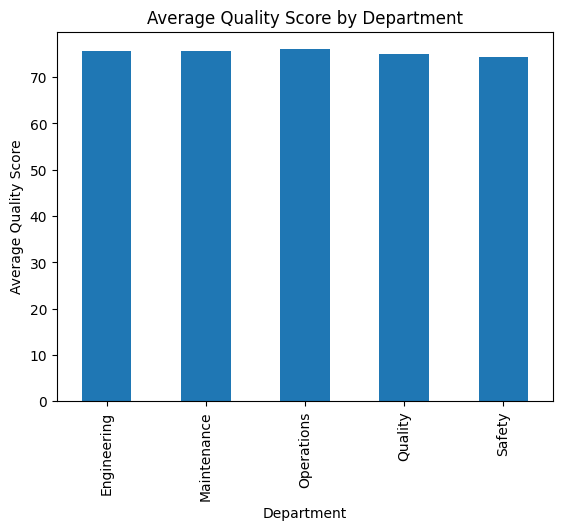

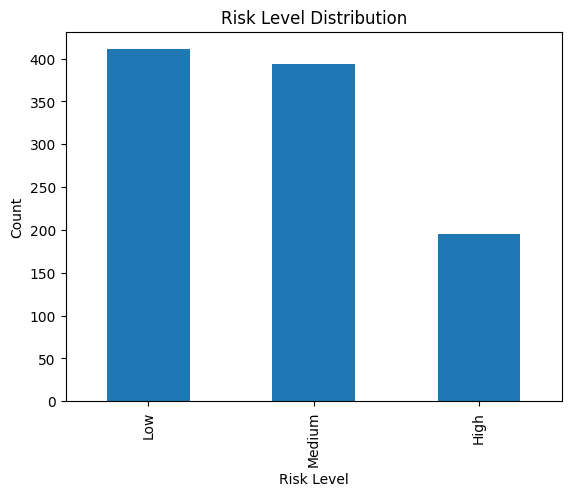

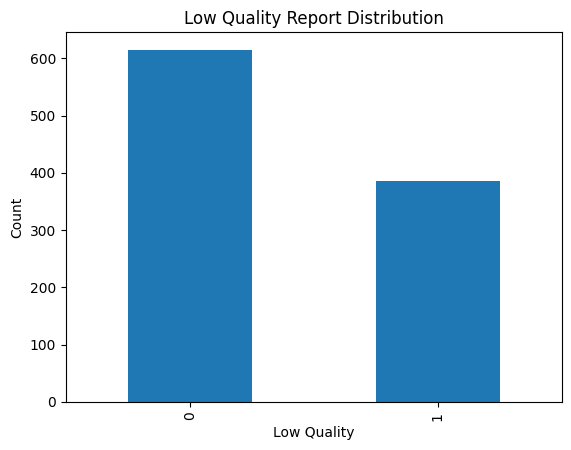

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_isp_safety_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.groupby("Department")["Quality_Score"].mean().plot(kind="bar")
plt.title("Average Quality Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Quality Score")
plt.show()

df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

df["Low_Quality"].value_counts().plot(kind="bar")
plt.title("Low Quality Report Distribution")
plt.xlabel("Low Quality")
plt.ylabel("Count")
plt.show()